In [2]:
import os
import glob
import pandas as pd
import numpy as np
import kagglehub

# =====================================================================
# 1. DATA ACQUISITION (Automated Download via kagglehub)
# This Data is used in evaluation Step.
# =====================================================================

print("Downloading the latest dataset version from Kaggle...")
# Automatically fetches and caches the dataset files locally
path = kagglehub.dataset_download("alfrandom/protein-secondary-structure")
print("Dataset directory path:", path)

# Dynamically locate the CSV file inside the downloaded directory path
csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded dataset directory!")

csv_path = csv_files[0]
print(f"Loading empirical data file from: {csv_path}")
df = pd.read_csv(csv_path)

# =====================================================================
# 2. DATA CLEANING (Filtering Out Noise)
# =====================================================================
# Keep only standard sequences to ensure neural network embedding stability
df_clean = df[df['has_nonstd_aa'] == False].copy()

# =====================================================================
# 3. LABEL MAPPING (Converting 3-State sst3 to Binary Targets)
# =====================================================================
# Project Specification: 'H' (Alpha-helix) -> 1, 'C' & 'E' (Others) -> 0
def map_to_binary(sst3_sequence):
    return [1 if char == 'H' else 0 for char in sst3_sequence]

# =====================================================================
# 4. AMINO ACID ENCODING (String to Integer Vector Representation)
# =====================================================================
# Define the 20 standard amino acid alphabet and assign a unique ID (1-20)
AA_ALPHABET = "ACDEFGHIKLMNPQRSTVWY"
aa_to_int = {aa: i + 1 for i, aa in enumerate(AA_ALPHABET)}

def encode_sequence(sequence):
    return [aa_to_int[aa] for aa in sequence if aa in aa_to_int]

# Execute the preprocessing pipeline on the cleaned dataframe
df_clean['binary_target'] = df_clean['sst3'].apply(map_to_binary)
df_clean['encoded_input'] = df_clean['seq'].apply(encode_sequence)

# =====================================================================
# 5. EXTRA STEP: Extracting columns into pure NumPy Arrays
# =====================================================================
# Now these columns securely exist, so no KeyError will occur
X_inputs = np.array(df_clean['encoded_input'].tolist(), dtype=object)
Y_targets = np.array(df_clean['binary_target'].tolist(), dtype=object)

print("\n✅ Execution Successful!")
print("Inputs Shape (Pure Array):", X_inputs.shape)
print("Targets Shape (Pure Array):", Y_targets.shape)

print("\n✅ Empirical data pipeline is successfully prepared.")
print("Sample rows from the preprocessed dataframe:")
print(df_clean[['seq', 'encoded_input', 'sst3', 'binary_target']].head(3))


# =====================================================================
# 5. EVALUATION METRICS DESIGN (Validation Framework)
# =====================================================================
def calculate_evaluation_metrics(y_true, y_pred):
    """
    Computes standard statistical metrics for binary classification.
    y_true: List or array of ground truth labels (0 or 1).
    y_pred: List or array of predicted labels (0 or 1).
    """
    # Cast to numpy arrays for fast element-wise boolean operations
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Extract the 4 foundational confusion matrix elements
    tp = np.sum((y_true == 1) & (y_pred == 1)) # True Positives
    tn = np.sum((y_true == 0) & (y_pred == 0)) # True Negatives
    fp = np.sum((y_true == 0) & (y_pred == 1)) # False Positives
    fn = np.sum((y_true == 1) & (y_pred == 0)) # False Negatives
    
    # Calculate performance metrics handling potential division by zero safely
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Also known as Recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    f1_denominator = precision + sensitivity
    f1_score = 2 * (precision * sensitivity) / f1_denominator if f1_denominator > 0 else 0
    
    return {
        "Sensitivity (Recall)": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1-Score": f1_score
    }
df_clean["seq_length"] = df_clean["seq"].apply(len)

print(df_clean["seq_length"].describe())
print("max length:", df_clean["seq_length"].max())
print("95% length:", df_clean["seq_length"].quantile(0.95))
print("99% length:", df_clean["seq_length"].quantile(0.99))


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset directory path: /Users/foroughasgari/.cache/kagglehub/datasets/alfrandom/protein-secondary-structure/versions/2
Loading empirical data file from: /Users/foroughasgari/.cache/kagglehub/datasets/alfrandom/protein-secondary-structure/versions/2/2018-06-06-ss.cleaned.csv

✅ Execution Successful!
Inputs Shape (Pure Array): (386333,)
Targets Shape (Pure Array): (386333,)

✅ Empirical data pipeline is successfully prepared.
Sample rows from the preprocessed dataframe:
   seq encoded_input sst3 binary_target
0  EDL    [4, 3, 10]  CEC     [0, 0, 0]
1  KCK     [9, 2, 9]  CEC     [0, 0, 0]
2  KAK     [9, 1, 9]  CEC     [0, 0, 0]
count    386333.000000
mean        262.267388
std         192.125696
min           3.000000
25%         134.000000
50%         226.000000
75%         338.000000
max        5037.000000
Name: seq_length, dtype: float64
max length: 5037
95% length: 580.0
99% length: 964.0


In [3]:
# Check unique values in the filtered dataframe
print(df_clean['has_nonstd_aa'].unique())

[False]


In [4]:
# Show 5 random rows from the dataset
df_clean[['seq', 'encoded_input', 'sst3', 'binary_target']].sample(5)

,seq,encoded_input,sst3,binary_target
324831,SMSRFAADPHWLIYLPPTMSPCETSKKEGMLEHPIEAFEYFRTRGV...,"[16, 11, 16, 15, 5, 1, 1, 3, 13, 7, 19, 10, 8,...",CCCCEECCHHHCCCCCCCCECCCCCCCCCCCCCHHHHHHHHHHCCC...,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, ..."
59968,IQRTPKIQVYSRHPAENGKSNFLNCYVSGFHPSDIEVDLLKNGERI...,"[8, 14, 15, 17, 13, 9, 8, 14, 18, 20, 16, 15, ...",CCECCEEEEEECCCCCCCCCEEEEEEEEEEECCCCEEEEEECCEEC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
380794,MTQFTDIDKLAVSTIRILAVDTVSKANSGHPGAPLGMAPAAHVLWS...,"[11, 17, 14, 5, 17, 3, 8, 3, 9, 10, 1, 18, 16,...",CCCCCHHHHHHHHHHHHHHHHHHHHHCCCCCHHHHHHHHHHHHHHH...,"[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
388771,MKEFYLTVEQIGDSIFERYIDSNGRERTREVEYKPSLFAHCPESQA...,"[11, 9, 4, 5, 20, 10, 17, 18, 4, 14, 8, 6, 3, ...",CCCEEEEEEEECCEEEEEEECCCCCEEEEEECCCCEEEEECCCCCC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
56522,GTRLAGILFLLTVLTTVLVSGWVVLGWMEDAQRLPLSKLVLTGERH...,"[6, 17, 15, 10, 1, 6, 8, 10, 5, 10, 10, 17, 18...",CCCHHHHHHHHHHHHHHHHHHHHHHHCCCCCCCCCCCCCCCCCCCC...,"[0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [7]:
lengths = df_clean["seq"].str.len()

print(lengths.describe())

count    386333.000000
mean        262.267388
std         192.125696
min           3.000000
25%         134.000000
50%         226.000000
75%         338.000000
max        5037.000000
Name: seq, dtype: float64


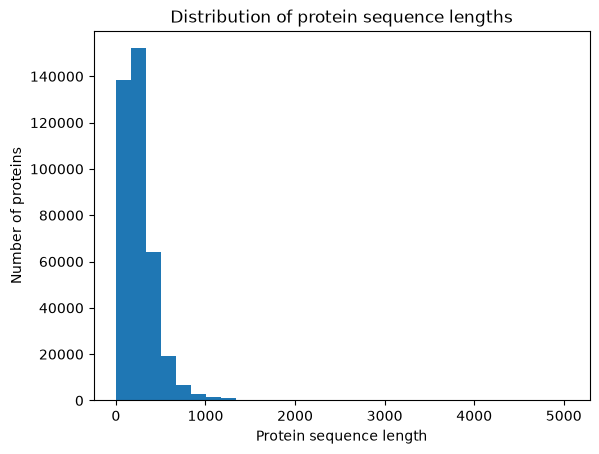

In [8]:
import matplotlib.pyplot as plt

plt.hist(lengths, bins=30)
plt.xlabel("Protein sequence length")
plt.ylabel("Number of proteins")
plt.title("Distribution of protein sequence lengths")
plt.show()

In [9]:
print("50–80:", ((lengths >= 50) & (lengths <= 80)).mean())
print("81–120:", ((lengths >= 81) & (lengths <= 120)).mean())
print("121–150:", ((lengths >= 121) & (lengths <= 150)).mean())
print("151–200:", ((lengths >= 151) & (lengths <= 200)).mean())
print(">200:", (lengths > 200).mean())

50–80: 0.04803886802318207
81–120: 0.10497679463053894
121–150: 0.09682838380360984
151–200: 0.1247136537650162
>200: 0.5760496773508864


In [10]:
print(lengths.quantile([0.01, 0.05, 0.95, 0.99]))

0.01     11.0
0.05     50.0
0.95    580.0
0.99    964.0
Name: seq, dtype: float64


In [18]:
from pathlib import Path

project_root = Path.cwd().parents[1]

output_path = project_root / "data" / "processed" / "real_proteins.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)

df_clean[["seq", "sst3", "binary_target"]].to_csv(
    output_path,
    index=False,
)

print("Saved to:", output_path.resolve())
print("File exists:", output_path.exists())

Saved to: /Volumes/Uni /1Documents/4/SBI/Project/SBI-Protein-HMM/data/processed/real_proteins.csv
File exists: True


In [17]:
print(Path.cwd())

/Volumes/Uni /1Documents/4/SBI/Project/SBI-Protein-HMM/src/preprocessing
